In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

from xgboost import XGBClassifier

## Why Walk-Forward Evaluation?

Fußballspiele sind zeitlich geordnet. Ein zufälliger Train/Test-Split
könnte dazu führen, dass Informationen aus späteren Spielen indirekt
im Training landen.

Deshalb trainieren wir das Modell ausschließlich auf der Vergangenheit
und testen es anschließend auf einer späteren, bisher ungesehenen Saison.

In [17]:
df = pd.read_csv("../data/processed/bundesliga_features.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print(df.shape)

(4896, 35)


In [18]:
def get_season(date):
    if date.month >= 8:
        start_year = date.year
    else:
        start_year = date.year - 1

    return f"{start_year}/{str(start_year + 1)[-2:]}"


df["Season"] = df["Date"].apply(get_season)

In [19]:
feature_columns = [
    "home_points_avg",
    "away_points_avg",

    "home_goals_avg",
    "away_goals_avg",

    "home_conceded_avg",
    "away_conceded_avg",

    "home_wins",
    "away_wins",

    "home_draws",
    "away_draws",

    "home_losses",
    "away_losses",

    "home_games_history",
    "away_games_history",

    "home_home_points_avg",
    "away_away_points_avg",

    "home_home_goals_avg",
    "away_away_goals_avg",

    "home_home_conceded_avg",
    "away_away_conceded_avg",

    "home_home_wins",
    "away_away_wins",

    "home_home_games",
    "away_away_games",

    "home_elo",
    "away_elo",
    "elo_difference",

    "points_avg_diff",
    "goals_avg_diff",
    "conceded_avg_diff",
    "wins_diff"
]

In [20]:
X = df[feature_columns]
y = df["FTR"]

In [21]:
label_mapping = {
    "A": 0,
    "D": 1,
    "H": 2
}

y_encoded = y.map(label_mapping)

In [22]:
test_seasons = [
    "2018/19",
    "2019/20",
    "2020/21",
    "2021/22",
    "2022/23",
    "2023/24",
    "2024/25",
    "2025/26"
]

In [23]:
df["Season"].unique()

<StringArray>
['2010/11', '2011/12', '2012/13', '2013/14', '2014/15', '2015/16', '2016/17',
 '2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24',
 '2024/25', '2025/26']
Length: 16, dtype: str

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [25]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=2000))
])

In [26]:
best_xgb_params = {
    "n_estimators": 200,
    "max_depth": 2,
    "learning_rate": 0.05,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

In [27]:
def create_xgb_model():
    return XGBClassifier(
        **best_xgb_params,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )

## Evaluation Procedure

Für jede Testsaison werden alle vorherigen Saisons zum Training verwendet.

Beispiel:

2010/11–2019/20 → Training
2020/21         → Test

Anschließend wird der Trainingszeitraum um eine Saison erweitert.

In [28]:
results = []

for test_season in test_seasons:

    print(f"Testing season: {test_season}")

    train_df = df[df["Season"] < test_season]
    test_df = df[df["Season"] == test_season]

    X_train = train_df[feature_columns]
    X_test = test_df[feature_columns]

    y_train = train_df["FTR"]
    y_test = test_df["FTR"]

    y_train_encoded = y_train.map(label_mapping)
    y_test_encoded = y_test.map(label_mapping)

    # -----------------------------------------
    # Logistic Regression
    # -----------------------------------------

    logistic_model.fit(
        X_train,
        y_train
    )

    logistic_probabilities = logistic_model.predict_proba(X_test)

    logistic_predictions = logistic_model.predict(X_test)

    logistic_accuracy = accuracy_score(
        y_test,
        logistic_predictions
    )

    logistic_log_loss = log_loss(
        y_test,
        logistic_probabilities,
        labels=logistic_model.classes_
    )

    # -----------------------------------------
    # XGBoost
    # -----------------------------------------

    xgb_model = create_xgb_model()

    xgb_model.fit(
        X_train,
        y_train_encoded
    )

    xgb_probabilities = xgb_model.predict_proba(X_test)

    xgb_predictions_encoded = xgb_model.predict(X_test)

    xgb_predictions = pd.Series(
        xgb_predictions_encoded,
        index=test_df.index
    ).map({
        0: "A",
        1: "D",
        2: "H"
    })

    xgb_accuracy = accuracy_score(
        y_test,
        xgb_predictions
    )

    xgb_log_loss = log_loss(
        y_test_encoded,
        xgb_probabilities,
        labels=[0, 1, 2]
    )

    results.append({
        "Season": test_season,
        "Logistic Accuracy": logistic_accuracy,
        "Logistic Log Loss": logistic_log_loss,
        "XGBoost Accuracy": xgb_accuracy,
        "XGBoost Log Loss": xgb_log_loss
    })

Testing season: 2018/19
Testing season: 2019/20
Testing season: 2020/21
Testing season: 2021/22
Testing season: 2022/23
Testing season: 2023/24
Testing season: 2024/25
Testing season: 2025/26


In [29]:
results_df = pd.DataFrame(results)

results_df

,Season,Logistic Accuracy,Logistic Log Loss,XGBoost Accuracy,XGBoost Log Loss
0,2018/19,0.529412,0.970156,0.542484,0.992810
1,2019/20,0.506536,1.013862,0.503268,1.028650
2,2020/21,0.490196,1.017107,0.500000,1.004990
3,2021/22,0.503268,1.001118,0.493464,1.007176
4,2022/23,0.519608,1.008945,0.506536,1.009917
5,2023/24,0.503268,0.971786,0.496732,0.981491
6,2024/25,0.503268,1.023499,0.483660,1.038209
7,2025/26,0.545752,0.955947,0.542484,0.969815


In [32]:
average_results = results_df.mean(numeric_only=True)

average_results

Logistic Accuracy    0.512663
Logistic Log Loss    0.995303
XGBoost Accuracy     0.508578
XGBoost Log Loss     1.004132
dtype: float64

In [33]:
print(
    "Average Logistic Accuracy:",
    results_df["Logistic Accuracy"].mean()
)

print(
    "Average XGBoost Accuracy:",
    results_df["XGBoost Accuracy"].mean()
)

print(
    "Average Logistic Log Loss:",
    results_df["Logistic Log Loss"].mean()
)

print(
    "Average XGBoost Log Loss:",
    results_df["XGBoost Log Loss"].mean()
)

Average Logistic Accuracy: 0.5126633986928104
Average XGBoost Accuracy: 0.508578431372549
Average Logistic Log Loss: 0.9953025132131387
Average XGBoost Log Loss: 1.0041321888566017


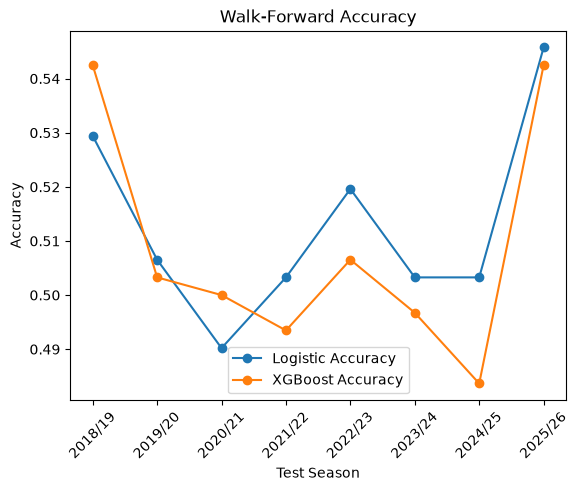

In [34]:
results_df.plot(
    x="Season",
    y=[
        "Logistic Accuracy",
        "XGBoost Accuracy"
    ],
    kind="line",
    marker="o",
    title="Walk-Forward Accuracy"
)

plt.ylabel("Accuracy")
plt.xlabel("Test Season")
plt.xticks(rotation=45)
plt.show()

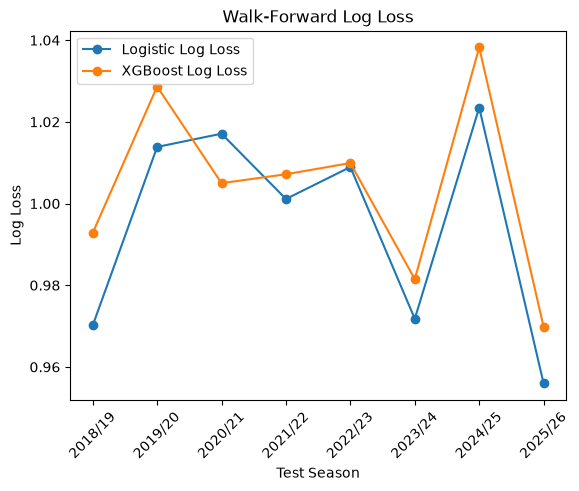

In [35]:
results_df.plot(
    x="Season",
    y=[
        "Logistic Log Loss",
        "XGBoost Log Loss"
    ],
    kind="line",
    marker="o",
    title="Walk-Forward Log Loss"
)

plt.ylabel("Log Loss")
plt.xlabel("Test Season")
plt.xticks(rotation=45)
plt.show()

## Results

Die Logistic Regression mit Elo-Rating erzielt über die getesteten
Zeiträume die beste durchschnittliche Performance.

Die Ergebnisse zeigen außerdem, dass eine höhere Modellkomplexität
nicht automatisch zu besseren Generalisierungsergebnissen führt.